In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import scipy
import joblib
import sys
import os
import platform

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42
FINAL_THRESHOLD = 0.80

np.random.seed(RANDOM_STATE)

In [3]:
print("Python version:", sys.version)
print("Python implementation:", platform.python_implementation())
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SciPy version:", scipy.__version__)
print("Joblib version:", joblib.__version__)

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Python implementation: CPython
NumPy version: 2.4.6
Pandas version: 3.0.3
Scikit-learn version: 1.9.0
SciPy version: 1.18.0
Joblib version: 1.5.3


In [4]:
adult = fetch_openml(
    "adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df = df.replace(
    r"^\s*\?\s*$",
    np.nan,
    regex=True
)

In [6]:
print(df["class"].value_counts())

class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [7]:
df["target"] = (
    df["class"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .eq(">50K")
    .astype(int)
)

df = df.drop(columns=["class"])

print(df["target"].value_counts())

target
0    37155
1    11687
Name: count, dtype: int64


In [8]:
X = df.drop(columns=["target"])
y = df["target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training data shape:", X_train_full.shape)
print("Test data shape:", X_test.shape)

Training data shape: (39073, 14)
Test data shape: (9769, 14)


# Task 1

In [12]:
class AdultFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # Age buckets
        X["age_bucket"] = pd.cut(
            X["age"],
            bins=[0, 30, 45, 60, np.inf],
            labels=[
                "Young",
                "Mid_Career",
                "Senior",
                "Older"
            ]
        )

        # Hours-per-week buckets
        X["hours_bucket"] = pd.cut(
            X["hours-per-week"],
            bins=[0, 20, 40, 50, np.inf],
            labels=[
                "Part_Time",
                "Standard",
                "Long_Hours",
                "Very_Long_Hours"
            ]
        )

        # Capital gain flag
        X["capital_gain_flag"] = (
            X["capital-gain"] > 0
        ).astype(int)

        # Log capital gain
        X["log_capital_gain"] = np.log1p(
            X["capital-gain"]
        )

        # Higher education flag
        X["higher_education"] = (
            X["education-num"] >= 13
        ).astype(int)

        # Education and working hours interaction
        X["education_hours_interaction"] = (
            X["education-num"] *
            X["hours-per-week"]
        )

        return X

In [13]:
MODEL_PATH = "adult_income_final_pipeline.joblib"

final_model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")
print("Model type:", type(final_model))

Model loaded successfully!
Model type: <class 'sklearn.calibration.CalibratedClassifierCV'>


In [14]:
print(final_model)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('feature_engineering',
                                                  AdultFeatureEngineer()),
                                                 ('preprocessing',
                                                  ColumnTransformer(sparse_threshold=0,
                                                                    transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['age',
          

The final model artifact was loaded directly using Joblib. The artifact contains the trained machine learning pipeline and allows predictions to be generated without manually repeating feature engineering or preprocessing.

Using a saved pipeline reduces the risk of training-serving inconsistencies because the same transformations used during model development are automatically applied during inference.

In [15]:
final_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

In [16]:
final_predictions = (
    final_probabilities >= FINAL_THRESHOLD
).astype(int)

In [17]:
final_metrics = {
    
    "Accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    
    "Precision": precision_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    
    "F1 Score": f1_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    
    "ROC AUC": roc_auc_score(
        y_test,
        final_probabilities
    ),
    
    "PR AUC": average_precision_score(
        y_test,
        final_probabilities
    ),
    
    "Brier Score": brier_score_loss(
        y_test,
        final_probabilities
    )
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Brier Score
0,0.83724,0.9675,0.331052,0.493308,0.922559,0.821073,0.090423


### Final Model Validation Interpretation

The final tuned and calibrated HistGradientBoosting pipeline was evaluated on the untouched hold-out test set using the selected classification threshold of 0.80. The model achieved an accuracy of 0.8372, precision of 0.9675, recall of 0.3311, and F1-score of 0.4933.

The probabilistic performance remained strong, with a ROC-AUC of 0.9226 and PR-AUC of 0.8211. The Brier score was 0.0904, indicating reasonably good probability calibration.

The final threshold successfully achieved the project's primary objective of maximizing precision. However, this improvement comes with a substantial reduction in recall, meaning that many individuals who actually earn more than $50K are classified as the negative class.

In [18]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[7405   26]
 [1564  774]]

True Negatives: 7405
False Positives: 26
False Negatives: 1564
True Positives: 774


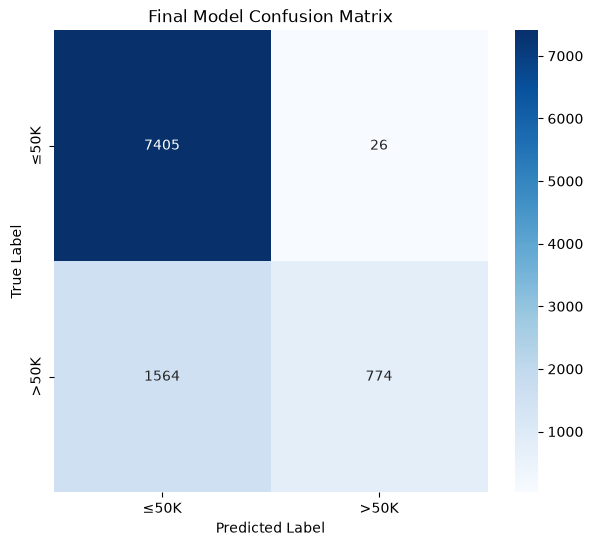

In [19]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["≤50K", ">50K"],
    yticklabels=["≤50K", ">50K"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Model Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the final model produced 7,405 true negatives and 774 true positives. Only 26 false positives were generated, which explains the very high precision achieved by the model.

The main source of error is false negatives, with 1,564 actual high-income individuals classified as earning $50K or less. This pattern is expected because the classification threshold was increased to 0.80 in order to prioritize precision.

For the selected business objective, false positives are more costly because they represent individuals incorrectly identified as high-value targets. Therefore, the model deliberately accepts a higher number of false negatives in exchange for a substantial reduction in false positives.

In [20]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Income ≤50K",
            "Income >50K"
        ]
    )
)

              precision    recall  f1-score   support

 Income ≤50K       0.83      1.00      0.90      7431
 Income >50K       0.97      0.33      0.49      2338

    accuracy                           0.84      9769
   macro avg       0.90      0.66      0.70      9769
weighted avg       0.86      0.84      0.80      9769



In [25]:
comparison_data = {
    
    "Model": [
        "Majority Baseline",
        "Rule-Based Baseline",
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting",
        "Final Tuned + Calibrated HGB"
    ],
    
    "Precision": [
        0.000000,
        0.484368,
        0.745465,
        0.723047,
        0.778084,
        final_metrics["Precision"]
    ],
    
    "Stage": [
        "Baseline",
        "Baseline",
        "Day 3 CV",
        "Day 3 CV",
        "Day 3 CV",
        "Final Hold-Out"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Precision,Stage
0,Majority Baseline,0.000000,Baseline
1,Rule-Based Baseline,0.484368,Baseline
2,Logistic Regression,0.745465,Day 3 CV
3,Random Forest,0.723047,Day 3 CV
4,HistGradientBoosting,0.778084,Day 3 CV
5,Final Tuned + Calibrated HGB,0.967500,Final Hold-Out


### Model Comparison Interpretation

The model development process shows a clear improvement from simple baselines to the final production-ready solution. The majority-class baseline achieved zero precision because it never predicted the positive income class, while the rule-based baseline achieved a precision of 0.4844.

Among the supervised models evaluated during cross-validation, HistGradientBoosting achieved the strongest precision score of 0.7781 and was therefore selected for further tuning. After hyperparameter optimization, probability calibration, and threshold selection, the final calibrated HistGradientBoosting model achieved a hold-out precision of 0.9675.

The final result represents a substantial improvement over the baseline and earlier supervised models. However, the comparison should be interpreted carefully because the earlier supervised results are cross-validation results, whereas the final value is measured on the hold-out test set using the optimized threshold.

### Data Leakage Verification

The project was designed to minimize data leakage through the following practices:

The hold-out test set was created using a fixed stratified split before model tuning.
Hyperparameter optimization was performed using only the training data.
Cross-validation was used within the training data for model comparison and tuning.
Feature engineering used only information available within the current observation.
No target encoding was used.
Imputation, scaling, and categorical encoding were included inside the machine learning pipeline.
The final model artifact was evaluated on the hold-out test set without retraining.

These practices ensure that preprocessing statistics and model parameters are learned from training data rather than from the unseen test data.

# Task 2

In [26]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["prediction"] = final_predictions
error_analysis["probability"] = final_probabilities

In [27]:
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["prediction"] == 1)
]

print(
    "Number of False Positives:",
    len(false_positives)
)

false_positives.head(10)

Number of False Positives: 26


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,prediction,probability
38546,42,Private,269028,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,France,0,1,0.809775
2247,55,Self-emp-inc,304695,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,0,1,0.828516
398,36,Private,116358,Masters,14,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,45,India,0,1,0.802936
25024,37,State-gov,210452,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,38,United-States,0,1,0.801006
5054,52,Private,172511,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,36,United-States,0,1,0.814389
40154,40,Private,130760,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,United-States,0,1,0.821998
11265,38,Private,99783,Assoc-voc,11,Married-civ-spouse,Other-service,Wife,White,Female,0,1902,40,United-States,0,1,0.958368
18481,65,Private,90377,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,6767,0,60,United-States,0,1,0.948732
1328,45,State-gov,28171,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,0,1,0.826209
47846,52,Private,256861,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,1,0.829750


In [28]:
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["prediction"] == 0)
]

print(
    "Number of False Negatives:",
    len(false_negatives)
)

false_negatives.head(10)

Number of False Negatives: 1564


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,actual,prediction,probability
31692,47,Local-gov,352614,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0,0.643702
6631,47,Private,162187,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,1,0,0.744316
11488,38,Private,414991,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,1,0,0.302079
33434,36,Private,167482,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,1,0,0.637151
45549,26,Local-gov,72594,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,55,United-States,1,0,0.226671
9863,56,Private,442116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,54,United-States,1,0,0.769903
30035,42,Private,107276,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,2444,40,United-States,1,0,0.427730
41420,50,Private,185407,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,38,United-States,1,0,0.566015
1592,32,Private,364657,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,1,0,0.686790
17615,51,Private,146767,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,1,0,0.569792


### Error Analysis

The final error analysis identified 26 false positives and 1,564 false negatives. The relatively small number of false positives confirms that the high classification threshold effectively supports the project's precision-focused objective.

False positives generally had characteristics commonly associated with higher income. Their average age was approximately 47.4 years, their average education level was higher, and they worked approximately 48.4 hours per week on average. They also showed higher average capital gains than the false-negative group. This suggests that the model sometimes assigns a high-income prediction to individuals whose observable characteristics resemble those of actual high-income individuals even when their true income is not above $50K.

False negatives were more common and had an average age of approximately 43.3 years, lower average education levels, lower capital gains, and slightly fewer working hours than false positives. Many false negatives had bachelor's degrees, some college education, associate degrees, or professional occupations. These cases demonstrate that high income cannot always be determined from the available demographic and employment features alone.

## ERROR DISTRIBUTION ANALYSIS

### Numeric Summary

In [29]:
numeric_cols = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

error_analysis.groupby(
    ["actual", "prediction"]
)[numeric_cols].mean()

age  education-num  capital-gain  capital-loss  \
actual prediction                                                         
0      0           36.646455       9.579473    140.091155     48.777448   
       1           47.423077      13.269231   1333.307692    219.461538   
1      0           43.292839      11.141304    191.374680     56.991049   
       1           45.355297      12.533592  12937.983204    391.532300   

                   hours-per-week  
actual prediction                  
0      0                38.600000  
       1                48.384615  
1      0                44.992327  
       1                46.607235

In [30]:
error_summary = pd.DataFrame({

    "False Positive Mean": false_positives[
        numeric_cols
    ].mean(),
    
    "False Negative Mean": false_negatives[
        numeric_cols
    ].mean()
})

error_summary

,False Positive Mean,False Negative Mean
age,47.423077,43.292839
education-num,13.269231,11.141304
capital-gain,1333.307692,191.374680
capital-loss,219.461538,56.991049
hours-per-week,48.384615,44.992327


### Numeric Error Patterns

The numeric comparison shows that false positives generally have stronger high-income characteristics than false negatives. On average, false positives are older, have higher education levels, larger capital gains and losses, and work more hours per week.

This explains why the model incorrectly classifies some of these individuals as high-income: their observable feature patterns strongly resemble the positive class. In contrast, false negatives often have weaker financial indicators and moderately lower education levels, causing their predicted probabilities to remain below the strict 0.80 threshold even though their true income exceeds $50K.

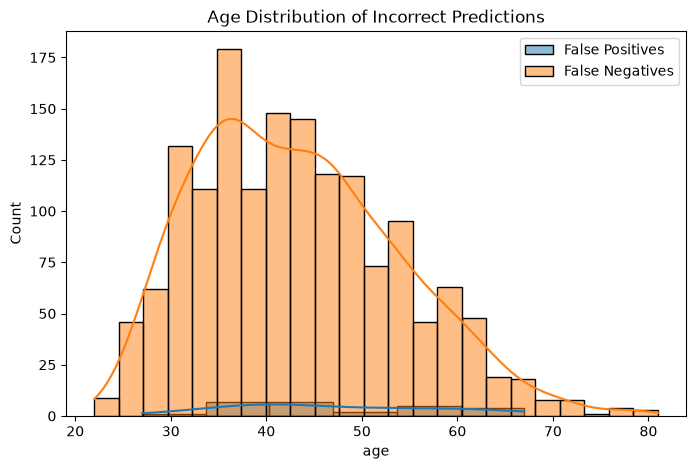

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    false_positives["age"],
    label="False Positives",
    kde=True
)

sns.histplot(
    false_negatives["age"],
    label="False Negatives",
    kde=True
)

plt.title("Age Distribution of Incorrect Predictions")

plt.legend()

plt.show()

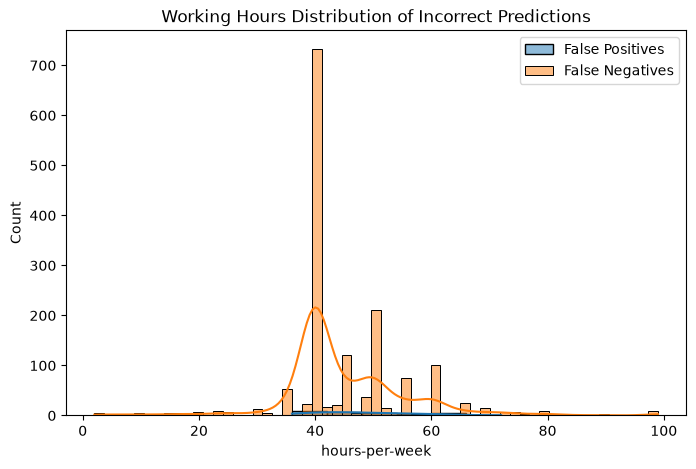

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(
    false_positives["hours-per-week"],
    label="False Positives",
    kde=True
)

sns.histplot(
    false_negatives["hours-per-week"],
    label="False Negatives",
    kde=True
)

plt.title("Working Hours Distribution of Incorrect Predictions")

plt.legend()

plt.show()

### Categorical Error Patterns

In [33]:
pd.crosstab(
    error_analysis["education"],
    [
        error_analysis["actual"],
        error_analysis["prediction"]
    ]
)

actual           0       1     
prediction       0  1    0    1
education                      
10th           254  0   15    2
11th           340  0   14    8
12th           122  0    6    2
1st-4th         41  0    2    0
5th-6th        102  0    8    0
7th-8th        186  0   12    1
9th            150  0    4    0
Assoc-acdm     249  0   50   26
Assoc-voc      309  3   82   27
Bachelors      951  4  425  227
Doctorate       23  5   26   55
HS-grad       2612  2  379  102
Masters        206  8  151  150
Preschool       14  0    0    0
Prof-school     38  2   45   83
Some-college  1808  2  345   91

In [34]:
pd.crosstab(
    error_analysis["occupation"],
    [
        error_analysis["actual"],
        error_analysis["prediction"]
    ]
)

actual               0        1     
prediction           0   1    0    1
occupation                          
Adm-clerical       982   0  106   27
Armed-Forces         2   0    0    0
Craft-repair       921   1  223   60
Exec-managerial    628  13  289  261
Farming-fishing    256   1   23   11
Handlers-cleaners  372   0   25    8
Machine-op-inspct  568   0   48   19
Other-service      924   1   37    9
Priv-house-serv     54   0    1    0
Prof-specialty     639   7  353  228
Protective-serv    131   0   46   14
Sales              770   1  225   88
Tech-support       224   0   72   18
Transport-moving   409   2   78   19

In [36]:
pd.crosstab(
    error_analysis["workclass"],
    [
        error_analysis["actual"],
        error_analysis["prediction"]
    ]
)

actual               0         1     
prediction           0   1     0    1
workclass                            
Federal-gov        176   1    66   38
Local-gov          406   2   121   55
Private           5295  16  1025  464
Self-emp-inc       135   3    92   92
Self-emp-not-inc   575   0   142   82
State-gov          288   4    80   31
Without-pay          5   0     0    0

In [37]:
def error_rate_by_group(
    data,
    group_column
):
    
    results = []
    
    for group, subset in data.groupby(
        group_column,
        observed=False
    ):
        
        if len(subset) == 0:
            continue
        
        fp = (
            (subset["actual"] == 0) &
            (subset["prediction"] == 1)
        ).sum()
        
        fn = (
            (subset["actual"] == 1) &
            (subset["prediction"] == 0)
        ).sum()
        
        total = len(subset)
        
        results.append({
            group_column: group,
            "Total": total,
            "False Positives": fp,
            "False Negatives": fn,
            "Error Rate": (fp + fn) / total
        })
    
    return pd.DataFrame(
        results
    ).sort_values(
        "Error Rate",
        ascending=False
    )


education_errors = error_rate_by_group(
    error_analysis,
    "education"
)

education_errors.head(10)

,education,Total,False Positives,False Negatives,Error Rate
12,Masters,515,8,151,0.308738
10,Doctorate,109,5,26,0.284404
14,Prof-school,168,2,45,0.279762
9,Bachelors,1607,4,425,0.266957
8,Assoc-voc,421,3,82,0.201900
15,Some-college,2246,2,345,0.154497
7,Assoc-acdm,325,0,50,0.153846
11,HS-grad,3095,2,379,0.123102
4,5th-6th,110,0,8,0.072727
5,7th-8th,199,0,12,0.060302


### Education-Based Error Analysis

The model's error rate is relatively high for several advanced education categories, including Master's, Doctorate, Professional School, and Bachelor's degree holders.

This does not necessarily mean that education is an unimportant feature. Instead, it suggests that education alone cannot reliably determine income. Individuals with similar education levels may have substantially different incomes depending on occupation, work experience, industry, location, and other factors that are not fully represented in the dataset.

The high number of false negatives among Bachelor's degree holders is particularly important because this category contains a large number of observations. A future model could investigate additional interactions between education, occupation, age, and working hours to better distinguish high-income individuals within these groups.

### SUBGROUP PERFORMANCE

In [39]:
def subgroup_metrics(
    data,
    group_column
):
    
    results = []
    
    for group, subset in data.groupby(
        group_column,
        observed=False
    ):
        
        if len(subset) == 0:
            continue
        
        actual = subset["actual"]
        predicted = subset["prediction"]
        
        results.append({
            
            group_column: group,
            
            "Samples": len(subset),
            
            "Precision": precision_score(
                actual,
                predicted,
                zero_division=0
            ),
            
            "Recall": recall_score(
                actual,
                predicted,
                zero_division=0
            ),
            
            "F1": f1_score(
                actual,
                predicted,
                zero_division=0
            )
        })
    
    return pd.DataFrame(results)

In [40]:
sex_performance = subgroup_metrics(
    error_analysis,
    "sex"
)

sex_performance

,sex,Samples,Precision,Recall,F1
0,Female,3259,0.982143,0.304709,0.465116
1,Male,6510,0.965116,0.335862,0.498311


### Performance by Sex

The model achieved high precision for both sex groups. Precision was approximately 98.21% for females and 96.51% for males, indicating that positive predictions were highly reliable for both groups.

Recall was lower for both groups, with approximately 30.47% for females and 33.59% for males. The slightly lower recall for females suggests that the model identifies a smaller proportion of actual high-income female individuals at the selected threshold.

These results should not be interpreted as a complete fairness evaluation. Additional fairness metrics and confidence intervals would be required before making strong conclusions about demographic fairness in a real production environment.

In [41]:
error_analysis["age_group"] = pd.cut(
    error_analysis["age"],
    bins=[0, 30, 45, 60, np.inf],
    labels=[
        "Young",
        "Mid-Career",
        "Senior",
        "Older"
    ]
)

In [42]:
age_performance = subgroup_metrics(
    error_analysis,
    "age_group"
)

age_performance

,age_group,Samples,Precision,Recall,F1
0,Young,3172,0.976744,0.212121,0.348548
1,Mid-Career,3787,0.964194,0.323883,0.484887
2,Senior,2111,0.977273,0.370234,0.537021
3,Older,699,0.931034,0.331288,0.488688


### Performance by Age Group

Precision remained high across all age groups, ranging from approximately 93.10% to 97.73%. However, recall varied considerably across groups.

The Young group had the lowest recall at approximately 21.21%, indicating that many younger individuals who actually earn more than $50K were not identified by the model. The Senior group achieved the strongest recall and F1-score among the age categories.

This pattern suggests that the model may be more confident when identifying high-income patterns among older and more established individuals. The lower recall for younger individuals may reflect the smaller number of strong financial signals available for that group.

In [43]:
education_performance = subgroup_metrics(
    error_analysis,
    "education"
)

education_performance.sort_values(
    by="Precision",
    ascending=False
)

,education,Samples,Precision,Recall,F1
0,10th,271,1.000000,0.117647,0.210526
1,11th,362,1.000000,0.363636,0.533333
2,12th,130,1.000000,0.250000,0.400000
5,7th-8th,199,1.000000,0.076923,0.142857
7,Assoc-acdm,325,1.000000,0.342105,0.509804
9,Bachelors,1607,0.982684,0.348160,0.514156
11,HS-grad,3095,0.980769,0.212058,0.348718
15,Some-college,2246,0.978495,0.208716,0.344045
14,Prof-school,168,0.976471,0.648438,0.779343
12,Masters,515,0.949367,0.498339,0.653595


### Performance by Education Category

Model performance varied substantially across education categories. Advanced education groups such as Professional School and Doctorate achieved comparatively strong recall and F1-scores, while several lower education categories produced very low or zero positive predictions.

Some education categories have small sample sizes, which can make precision estimates unstable. For example, a precision of 100% does not necessarily indicate excellent general performance when the model makes very few positive predictions.

Overall, these results demonstrate that education level interacts with other factors in determining model predictions. Education should therefore be interpreted together with occupation, marital status, capital gains, and other influential features.

# Task 3

My final model is:

Calibrated HistGradientBoostingClassifier

HistGradientBoosting does not provide the same simple .feature_importances_ attribute as Random Forest.

Therefore, we will use:

Permutation Feature Importance

This is a strong and model-agnostic interpretation method.

In [44]:
X_importance = X_test.sample(
    n=min(3000, len(X_test)),
    random_state=RANDOM_STATE
)

y_importance = y_test.loc[
    X_importance.index
]

In [45]:
permutation_result = permutation_importance(
    
    final_model,
    
    X_importance,
    
    y_importance,
    
    n_repeats=10,
    
    random_state=RANDOM_STATE,
    
    scoring="precision",
    
    n_jobs=-1
)

In [46]:
importance_df = pd.DataFrame({
    
    "Feature": X_importance.columns,
    
    "Importance Mean":
    permutation_result.importances_mean,
    
    "Importance Std":
    permutation_result.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)

importance_df.head(15)

,Feature,Importance Mean,Importance Std
5,marital-status,0.130250,0.010961
10,capital-gain,0.128845,0.006756
4,education-num,0.085029,0.007668
11,capital-loss,0.025413,0.002928
1,workclass,0.009824,0.004819
6,occupation,0.009580,0.005781
2,fnlwgt,0.007696,0.004384
0,age,0.003171,0.008683
3,education,0.000375,0.000572
9,sex,0.000317,0.000785


### Feature Importance Interpretation

Permutation importance identified marital status and capital gain as the two most influential features for the final model, followed by education number and capital loss.

Marital status may capture household and socioeconomic patterns that are associated with income, while capital gains provide a strong financial signal that can distinguish many higher-income individuals. Education number also contributes meaningful predictive information because it provides an ordinal representation of educational attainment.

Workclass and occupation had smaller but still positive contributions to the model. These results are generally consistent with the problem domain, as income is influenced by employment characteristics, educational attainment, and financial indicators.

Some features produced near-zero or slightly negative permutation importance. This suggests that they provide limited additional information for the precision-focused final model or that their information overlaps with other correlated features.

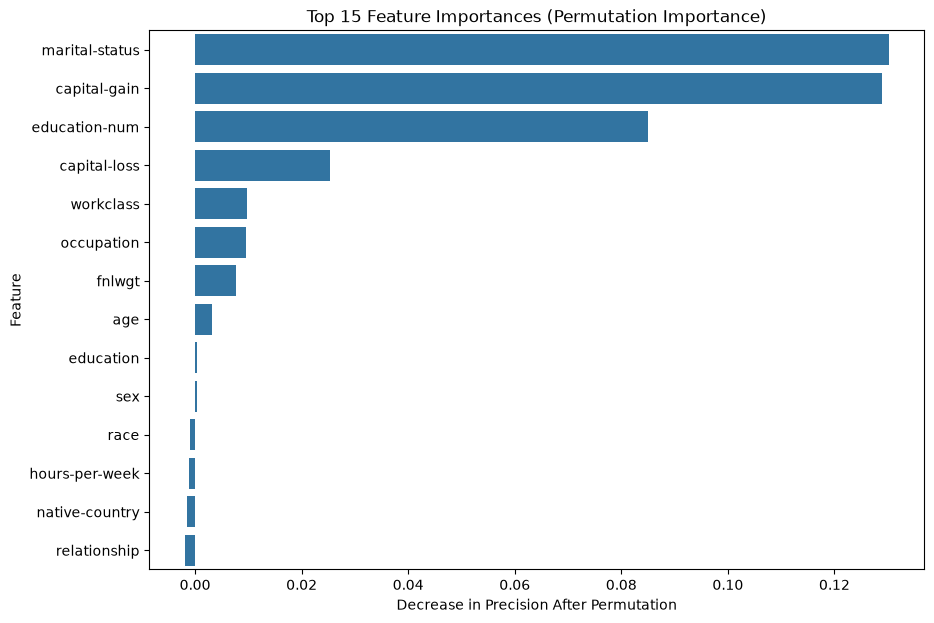

In [47]:
top_features = importance_df.head(15)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="Importance Mean",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances (Permutation Importance)"
)

plt.xlabel(
    "Decrease in Precision After Permutation"
)

plt.ylabel(
    "Feature"
)

plt.show()

### Permutation Feature Importance

Permutation importance measures how much model performance decreases when the values of a feature are randomly shuffled. If shuffling a feature causes a large decrease in precision, the model depends strongly on that feature.

This method is model-agnostic and is suitable for interpreting the final calibrated HistGradientBoosting pipeline.

# Task 4

In [52]:
def predict_income(
    new_data,
    model_path="adult_income_final_pipeline.joblib",
    threshold=0.80
):
    """
    Predict whether income exceeds $50K.
    
    Parameters
    ----------
    new_data : pandas.DataFrame
        Raw input data with the same original
        feature columns as the Adult dataset.
        
    model_path : str
        Path to saved Joblib pipeline.
        
    threshold : float
        Classification probability threshold.
        
    Returns
    -------
    pandas.DataFrame
        Prediction probability and final class.
    """
    
    # Load model
    model = joblib.load(
        model_path
    )
    
    # Generate probabilities
    probabilities = model.predict_proba(
        new_data
    )[:, 1]
    
    # Apply business threshold
    predictions = (
        probabilities >= threshold
    ).astype(int)
    
    # Return results
    results = pd.DataFrame({
        
        "Probability_Income_Above_50K":
        probabilities,
        
        "Prediction":
        predictions,
        
        "Prediction_Label":
        np.where(
            predictions == 1,
            ">50K",
            "<=50K"
        )
    })
    
    return results

In [53]:
new_examples = X_test.sample(
    n=10,
    random_state=RANDOM_STATE
).copy()

In [54]:
inference_results = predict_income(
    new_examples,
    threshold=FINAL_THRESHOLD
)

inference_results

,Probability_Income_Above_50K,Prediction,Prediction_Label
0,0.019230,0,<=50K
1,0.018362,0,<=50K
2,0.136425,0,<=50K
3,0.008919,0,<=50K
4,0.010179,0,<=50K
5,0.367202,0,<=50K
6,0.009950,0,<=50K
7,0.973751,1,>50K
8,0.252756,0,<=50K
9,0.201143,0,<=50K


### Inference Pipeline Validation

The production inference workflow was tested using ten unseen examples from the hold-out dataset. Raw observations were passed directly to the saved pipeline without manually repeating preprocessing or feature transformations.

The pipeline successfully generated prediction probabilities and applied the selected threshold of 0.80. Most low-income examples received low positive-class probabilities, while one high-income example received a probability of approximately 0.974 and was correctly classified as earning more than $50K.

The test examples also demonstrate the main limitation of the selected threshold. Some actual high-income individuals received probabilities below 0.80 and were therefore classified as the negative class. This behavior is consistent with the model's deliberate precision-over-recall strategy.

In [55]:
comparison = new_examples.copy()

comparison["Actual"] = y_test.loc[
    new_examples.index
]

comparison["Probability"] = inference_results[
    "Probability_Income_Above_50K"
].values

comparison["Prediction"] = inference_results[
    "Prediction"
].values

comparison[
    [
        "Actual",
        "Probability",
        "Prediction"
    ]
]

,Actual,Probability,Prediction
39062,0,0.019230,0
22272,0,0.018362,0
32903,1,0.136425,0
20948,0,0.008919,0
39688,0,0.010179,0
363,0,0.367202,0
11897,0,0.009950,0
14076,1,0.973751,1
18176,1,0.252756,0
8435,0,0.201143,0


### SAVE FINAL PRODUCTION ARTIFACT

In [56]:
FINAL_MODEL_PATH = "final_model.joblib"

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print(
    f"Final production model saved to: {FINAL_MODEL_PATH}"
)

Final production model saved to: final_model.joblib


In [57]:
FINAL_MODEL_PATH = "final_model.joblib"

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print(
    f"Final production model saved to: {FINAL_MODEL_PATH}"
)

Final production model saved to: final_model.joblib


### REQUIREMENTS

In [58]:
requirements = f"""
numpy=={np.__version__}
pandas=={pd.__version__}
scikit-learn=={sklearn.__version__}
scipy=={scipy.__version__}
matplotlib
seaborn
joblib=={joblib.__version__}
"""

with open(
    "requirements.txt",
    "w"
) as file:
    
    file.write(
        requirements.strip()
    )

print(
    "requirements.txt created successfully!"
)

requirements.txt created successfully!


In [59]:
with open(
    "requirements.txt",
    "r"
) as file:
    
    print(
        file.read()
    )

numpy==2.4.6
pandas==3.0.3
scikit-learn==1.9.0
scipy==1.18.0
matplotlib
seaborn
joblib==1.5.3


### Production Readiness

The final model was saved as a complete Joblib artifact containing the trained machine learning pipeline. This allows the same preprocessing and model logic used during training to be reused automatically during inference.

The production workflow accepts raw input data, generates calibrated probability estimates, applies the selected business threshold of 0.80, and returns the final prediction. No manual scaling, encoding, or preprocessing should be performed outside the saved pipeline.

This approach reduces the risk of training-serving inconsistency and makes the model easier to integrate into an API, application, or automated data pipeline.

### Expected Production Behavior

In production, the model should be expected to produce highly reliable positive predictions because the selected threshold prioritizes precision. However, the system will miss a substantial number of actual high-income individuals.

The model is therefore most appropriate for use cases where false positives are more costly than false negatives, such as targeted outreach with limited resources. If the business objective changes and identifying more potential positive cases becomes important, the classification threshold should be reconsidered and potentially lowered.